In [1]:
from utils import *

In [2]:
def check_inclusion_full(G1,G2,B1,B2):

    if len(B1) != len(B2):
        return False
    
    V = list(G1.nodes())
    V.sort()
    IG = induced_graph(V, B1, B2)
    IG_cleaned = IG_clean_up(IG, G1, G2, B2)
    unremovable = get_removable(V, G1, G2, B2)[1] & IG_cleaned.nodes
    unremovable_neighbors = neighbors_of_set(IG_cleaned, unremovable)

    if IG_cleaned.subgraph(unremovable).number_of_edges() > 0:
        return False

    for i in V:
        X = get_j(unremovable_neighbors,i)
        Y = list(G2.predecessors(i))
        if not path_rank(G1, X, Y + [i]) == path_rank(G1, X, Y):
            return False
    
    if is_vertex_cover(IG_cleaned.edges, unremovable_neighbors):
        return True

    remain = IG_cleaned.nodes - unremovable - unremovable_neighbors
    IG_remain = IG_cleaned.subgraph(remain).copy()
    IG_remain.remove_nodes_from(list(nx.isolates(IG_remain)))

    for cover in minimal_vertex_covers_fast(IG_remain):
        for i in V:
            X = list(get_j(unremovable_neighbors,i)) + list(get_j(cover,i))
            Y = list(G2.predecessors(i))
            if path_rank(G1, X, Y + [i]) != path_rank(G1, X, Y):
                break
        else:
            return True
            
    return False

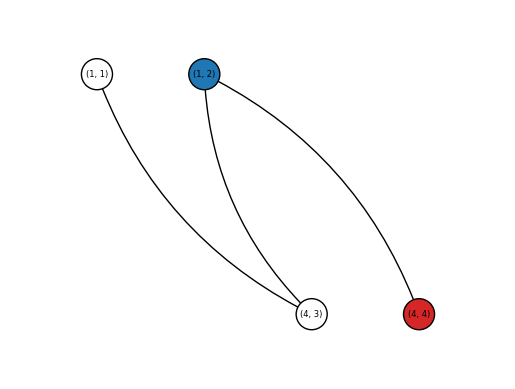

False

In [63]:
n = 4

# Generate DAGs
G1 = nx.DiGraph()
G2 = nx.DiGraph()
V = range(1,n+1)
G1.add_nodes_from(V)
G2.add_nodes_from(V)

# Edge Sets
E1 = [(1,2),(3,4)]
E2 = [(2,1),(3,4)]
B = [(1,2),(1,3),(2,3),(2,4),(3,4)]

# Add Edges
G1.add_edges_from(E1)
G2.add_edges_from(E2)
check_inclusion_full(G1,G2,B,B)
plot_auxiliary(G1,G2,B,B)

In [2]:
def random_reverse_edge(edges):
    """
    Returns:
        reversed_edges: edge list with one randomly chosen edge reversed.
        removed_edges: edge list with that same edge removed.
    Raises:
        ValueError if no edge can be reversed without creating a cycle.
    """
    edges = list(edges)
    candidates = edges[:]
    random.shuffle(candidates)

    for u, v in candidates:
        removed_edges = [e for e in edges if e != (u, v)]
        reversed_edges = removed_edges + [(v, u)]

        G = nx.DiGraph(reversed_edges)
        if nx.is_directed_acyclic_graph(G):
            return reversed_edges, removed_edges

In [3]:
A, B = random_reverse_edge(E1)

NameError: name 'E1' is not defined

In [4]:
from collections import deque

def canonical(edges):
    """Convert edge list to hashable representation."""
    return tuple(sorted(edges))


def is_acyclic(edges):
    """Check whether directed edge set is a DAG."""
    G = nx.DiGraph()
    G.add_edges_from(edges)
    return nx.is_directed_acyclic_graph(G)


def generate_neighbors(edges, n):
    """
    Generate all DAGs differing by one edge addition or removal.
    """
    edges = set(edges)
    neighbors = []

    # ---------
    # Remove one edge
    # ---------
    for e in edges:
        new_edges = edges.copy()
        new_edges.remove(e)

        neighbors.append(new_edges)


    # ---------
    # Add one edge
    # ---------
    for u in range(1, n + 1):
        for v in range(1, n + 1):

            if u == v:
                continue

            if (u, v) in edges:
                continue

            new_edges = edges.copy()
            new_edges.add((u, v))

            if is_acyclic(new_edges):
                neighbors.append(new_edges)

    return neighbors


def find_equivalence_class(edges, confounding, n):
    start = set(edges)
    visited = {canonical(start)}
    result = [start]
    queue = deque([start])
    while queue:
        current = queue.popleft()
        for neighbor in generate_neighbors(current, n):
            key = canonical(neighbor)
            if key in visited:
                continue
            if get_solver(start, neighbor, confounding, confounding, n) and get_solver(neighbor, start, confounding, confounding, n):
                visited.add(key)
                result.append(neighbor)
                queue.append(neighbor)
    return result

In [ ]:
n = 5
count = 0
while count < 2000:
    num_confounding = random.randint(1, n * (n - 1) // 2)
    G1 = random_dag(n,random.uniform(0.1,0.9))
    B = random_confounding(n,num_confounding)
    E1 = G1.edges()
    try:
        E2, E_reduced = random_reverse_edge(E1)
        G2 = nx.DiGraph()
        G_r = nx.DiGraph()
        V = range(1,n+1)
        G2.add_nodes_from(V)
        G_r.add_nodes_from(V)
        G2.add_edges_from(E2)
        G_r.add_edges_from(E_reduced)
        if check_inclusion_full(G1,G2,B,B):
            count = count + 1
            print(f"Count: {count}")
            if check_inclusion_full(G1,G_r,B,B) == False:
                print ("Stop")
                print (E1,E2,B)
                break
    except Exception:
        continue


Count: 1
Count: 2
Count: 3
Count: 4
Count: 5
Count: 6
Count: 7
Count: 8
Count: 9
Count: 10
Count: 11
Count: 12
Count: 13
Count: 14
Count: 15
Count: 16
Count: 17
Count: 18
Count: 19
Count: 20
Count: 21
Count: 22
Count: 23
Count: 24
Count: 25
Count: 26
Count: 27
Count: 28
Count: 29
Count: 30
Count: 31
Count: 32
Count: 33
Count: 34
Count: 35
Count: 36
Count: 37
Count: 38
Count: 39
Count: 40
Count: 41
Count: 42
Count: 43
Count: 44
Count: 45
Count: 46
Count: 47
Count: 48
Count: 49
Count: 50
Count: 51
Count: 52
Count: 53
Count: 54
Count: 55
Count: 56
Count: 57
Count: 58
Count: 59
Count: 60
Count: 61
Count: 62
Count: 63
Count: 64
Count: 65
Count: 66
Count: 67
Count: 68
Count: 69
Count: 70
Count: 71
Count: 72
Count: 73
Count: 74
Count: 75
Count: 76
Count: 77
Count: 78
Count: 79
Count: 80
Count: 81
Count: 82
Count: 83
Count: 84
Count: 85
Count: 86
Count: 87
Count: 88
Count: 89
Count: 90
Count: 91
Count: 92
Count: 93
Count: 94
Count: 95
Count: 96
Count: 97
Count: 98
Count: 99
Count: 100
Count: 1

In [ ]:
n = 4
count = 0
num_confounding = random.randint(1, 2)
G1 = random_dag(n,0.3)
B = random_confounding(n,num_confounding)
E1 = G1.edges()
E2, E_reduced = random_reverse_edge(E1)
G2 = nx.DiGraph()
G_r = nx.DiGraph()
V = range(1,n+1)
G2.add_nodes_from(V)
G_r.add_nodes_from(V)
G2.add_edges_from(E2)
G_r.add_edges_from(E_reduced)
check_inclusion_full(G2,G1,B,B)

True

In [5]:
n = 7
for i in range(10000):
    num_confounding = random.randint(1, 4)

    G1 = random_dag(n,0.3)
    B = random_confounding(n,num_confounding)
    E1 = G1.edges()
    try:
        E2, E_reduced = random_reverse_edge(E1)
        G2 = nx.DiGraph()
        G_r = nx.DiGraph()
        V = range(1,n+1)
        G2.add_nodes_from(V)
        G_r.add_nodes_from(V)
        G2.add_edges_from(E2)
        G_r.add_edges_from(E_reduced)
        if check_inclusion_full(G1,G2,B,B):
            if not check_inclusion_full(G1,G_r,B,B):
                print (E1,E2,B)
            break
    except Exception:
        continue

[(1, 3), (1, 4), (3, 4), (2, 3), (2, 4)]
(2, 4)


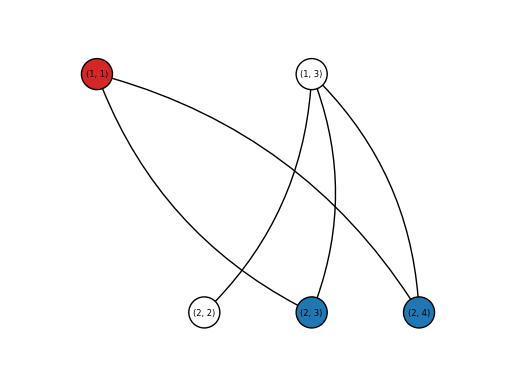

In [27]:
n = 4
for i in range(1000):
    num_confounding = random.randint(1, 5)
    G1 = random_dag(n,0.3)
    B = random_confounding(n,num_confounding)
    E1 = G1.edges()
    try:
        E2, E_reduced = random_reverse_edge(E1)
        G2 = nx.DiGraph()
        V = range(1,n+1)
        G2.add_nodes_from(V)
        G2.add_edges_from(E2)
        if check_inclusion_full(G1,G2,B,B):
            print (B)
            print (next(x for x in E1 if x not in E_reduced))
            plot_auxiliary(G1,G2,B,B)
            break
    except Exception:
        continue

True
[(1, 3)]
(1, 3)


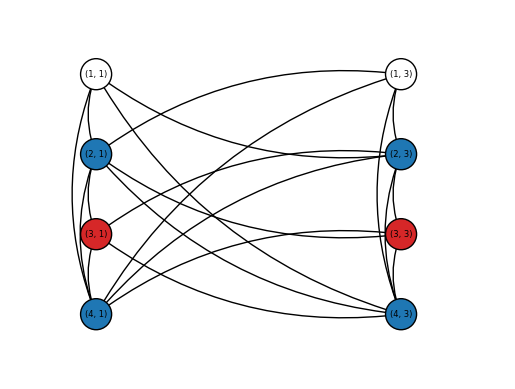

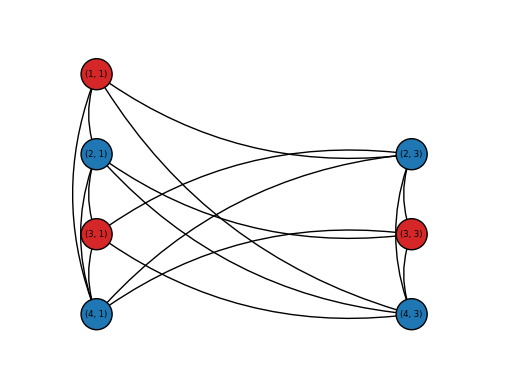

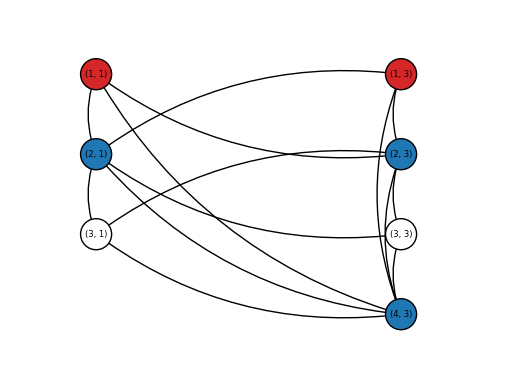

In [36]:
n = 4
for i in range(1000):
    num_confounding = random.randint(1, 5)

    G1 = random_dag(n,0.3)
    B = random_confounding(n,num_confounding)
    E1 = G1.edges()
    try:
        E2, E_reduced = random_reverse_edge(E1)
        G2 = nx.DiGraph()
        G_r = nx.DiGraph()
        V = range(1,n+1)
        G2.add_nodes_from(V)
        G_r.add_nodes_from(V)
        G2.add_edges_from(E2)
        G_r.add_edges_from(E_reduced)
        if check_inclusion_full(G1,G2,B,B) and check_inclusion_full(G2,G1,B,B):
            print (check_inclusion_full(G1,G_r,B,B))
            print (B)
            print (next(x for x in E1 if x not in E_reduced))
            plot_auxiliary(G1,G2,B,B)
            plot_auxiliary(G1,G_r,B,B)
            plot_auxiliary(G2,G1,B,B)
            break
    except Exception:
        continue

In [ ]:
get_solver(E1,E_reduced,B,B,n)

False

In [ ]:
G1 = nx.DiGraph()
G2 = nx.DiGraph()
V = range(1,n+1)
G1.add_nodes_from(V)
G2.add_nodes_from(V)
G1.add_edges_from(E1)
G2.add_edges_from(E_reduced)

In [ ]:
check_inclusion_full(G1,G2,B,B)

False

In [ ]:
E_reduced

[(5, 1), (5, 6), (5, 4), (5, 2), (3, 6), (1, 6), (1, 4)]

In [ ]:
E1 = [(4, 2), (4, 1), (4, 3), (2, 1), (2, 3), (1, 3)]
B1 = [(1, 2), (3, 4)]
E2 = [(4, 2), (4, 1), (4, 3), (2, 3), (1, 3), (1, 2)]

In [ ]:
find_equivalence_class(E1,B1,4)

[{(1, 3), (2, 1), (2, 3), (4, 1), (4, 2), (4, 3)},
 {(1, 3), (2, 3), (4, 1), (4, 2), (4, 3)},
 {(1, 3), (2, 1), (2, 3), (4, 2), (4, 3)},
 {(1, 3), (2, 1), (2, 3), (4, 1), (4, 2)},
 {(1, 3), (2, 3), (4, 1), (4, 2)},
 {(1, 2), (1, 3), (2, 3), (4, 1), (4, 2), (4, 3)},
 {(1, 3), (2, 1), (2, 3), (4, 2)},
 {(1, 2), (1, 3), (2, 3), (4, 1), (4, 2)},
 {(1, 2), (1, 3), (2, 3), (4, 1), (4, 3)},
 {(1, 2), (1, 3), (2, 3), (4, 1)}]

In [ ]:
get_solver(E1,E2,B1,B2,n)

True

In [ ]:
def enumerate_dags(n):
    vertices = range(1, n + 1)

    edges = [(u, v)
             for u in vertices
             for v in vertices
             if u != v]

    G = nx.DiGraph()
    G.add_nodes_from(vertices)

    def dfs(i):
        if i == len(edges):
            yield G.copy()
            return

        # Don't include this edge
        yield from dfs(i + 1)

        # Include this edge if it doesn't create a cycle
        u, v = edges[i]
        if not nx.has_path(G, v, u):
            G.add_edge(u, v)
            yield from dfs(i + 1)
            G.remove_edge(u, v)

    yield from dfs(0)

In [ ]:
for G in enumerate_dags(3):
    print (G.edges())

[]
[(3, 2)]
[(3, 1)]
[(3, 1), (3, 2)]
[(2, 3)]
[(2, 3), (3, 1)]
[(2, 1)]
[(2, 1), (3, 2)]
[(2, 1), (3, 1)]
[(2, 1), (3, 1), (3, 2)]
[(2, 1), (2, 3)]
[(2, 1), (2, 3), (3, 1)]
[(1, 3)]
[(1, 3), (3, 2)]
[(1, 3), (2, 3)]
[(1, 3), (2, 1)]
[(1, 3), (2, 1), (2, 3)]
[(1, 2)]
[(1, 2), (3, 2)]
[(1, 2), (3, 1)]
[(1, 2), (3, 1), (3, 2)]
[(1, 2), (2, 3)]
[(1, 2), (1, 3)]
[(1, 2), (1, 3), (3, 2)]
[(1, 2), (1, 3), (2, 3)]


In [ ]:
n = 4
G1 = random_dag(n,0.3)
B = random_confounding(n,2)
print (B)
print ("---")
for G in enumerate_dags(n):
    if check_inclusion_full(G1,G,B,B) and check_inclusion_full(G,G1,B,B):
        print (G.edges())

[(1, 3), (1, 4)]
---
[(4, 3)]
[(4, 1), (4, 3)]
[(3, 1), (4, 3)]
[(3, 1), (4, 1), (4, 3)]
